# Model Baseline — Riesgo de retraso en el pago

## Objetivo del notebook

El objetivo de este notebook es construir y evaluar los primeros modelos baseline para predecir si una factura será pagada después de su fecha de vencimiento.

La variable objetivo es:

`late_payment`

donde:

- `0`: la factura se paga antes o en la fecha de vencimiento;
- `1`: la factura se paga después de la fecha de vencimiento.

El dataset de entrada será:

`gold_invoice_risk.parquet`

generado durante la fase de feature engineering.

## Metodología de evaluación

La evaluación respetará estrictamente el orden temporal de las facturas.

No se utilizará un `train_test_split` aleatorio, ya que el objetivo del sistema es predecir el comportamiento de facturas futuras utilizando información histórica.

El dataset se dividirá en:

- **train**: período más antiguo;
- **validation**: período posterior utilizado para comparar decisiones de modelado;
- **test**: período más reciente, reservado para la evaluación final.

Las facturas correspondientes a una misma fecha permanecerán siempre dentro del mismo conjunto.

## Modelos baseline

Se evaluarán inicialmente dos referencias:

1. **Dummy Classifier**
   - representa un modelo sin capacidad predictiva real;
   - permite establecer el rendimiento mínimo que debe superar cualquier modelo útil.

2. **Regresión logística**
   - modelo lineal interpretable;
   - adecuado como primer baseline supervisado;
   - permite estimar probabilidades de retraso.

No se realizará todavía optimización de hiperparámetros ni se utilizarán modelos complejos.

## Métricas

Dado que aproximadamente el 35 % de las facturas pertenecen a la clase positiva, la accuracy no será suficiente para evaluar el modelo.

Se utilizarán principalmente:

- Accuracy;
- Balanced Accuracy;
- Precision;
- Recall;
- F1-score;
- ROC-AUC;
- PR-AUC / Average Precision;
- matriz de confusión.

Especialmente relevante será la capacidad de detectar facturas que realmente terminarán pagándose tarde.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    fbeta_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    classification_report,
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

In [2]:
PROJECT_ROOT = Path("..")

GOLD_DIR = (
    PROJECT_ROOT
    / "data"
    / "gold"
)

GOLD_FILE = (
    GOLD_DIR
    / "gold_invoice_risk.parquet"
)

print(GOLD_FILE)

..\data\gold\gold_invoice_risk.parquet


In [3]:
df = pd.read_parquet(
    GOLD_FILE
)

print(
    f"Filas: {df.shape[0]:,}"
)

print(
    f"Columnas: {df.shape[1]}"
)

display(
    df.head()
)

Filas: 2,466
Columnas: 48


,invoice_id,customer_id,invoice_date,due_date,invoice_amount,log_invoice_amount,paperless_bill,country_code,invoice_year,invoice_month,...,amount_diff_vs_previous_avg,open_amount_vs_current_invoice,overdue_amount_vs_current_invoice,is_new_customer,has_payment_history,has_3_payment_history,has_5_payment_history,has_open_invoices,has_overdue_invoices,late_payment
0,280670965,3993-QUNVJ,2012-01-03,2012-02-02,50.39,3.939444,PAPER,770,2012,1,...,NaN,0.0,0.0,1,0,0,0,0,0,0
1,5133177585,6708-DPYTF,2012-01-03,2012-02-02,55.37,4.031937,PAPER,391,2012,1,...,NaN,0.0,0.0,1,0,0,0,0,0,1
2,5928070131,1604-LIFKX,2012-01-03,2012-02-02,97.60,4.591071,PAPER,818,2012,1,...,NaN,0.0,0.0,1,0,0,0,0,0,1
3,6050714721,8887-NCUZC,2012-01-03,2012-02-02,15.99,2.832625,PAPER,818,2012,1,...,NaN,0.0,0.0,1,0,0,0,0,0,1
4,6393629835,5164-VMYWJ,2012-01-03,2012-02-02,71.33,4.281239,PAPER,406,2012,1,...,NaN,0.0,0.0,1,0,0,0,0,0,0


## 1. Validación del dataset de entrada

Antes de entrenar cualquier modelo se comprobará que el dataset Gold conserva las propiedades definidas durante el feature engineering.

En particular se verificará:

- unicidad de las facturas;
- ausencia de target nulo;
- formato correcto de las fechas;
- distribución esperada de la variable objetivo;
- orden temporal disponible.

Estas comprobaciones permiten detectar cambios accidentales en el pipeline de datos antes de que afecten al modelado.

In [4]:
checks = pd.Series({
    "rows": len(df),

    "columns": df.shape[1],

    "duplicated_invoice_id": (
        df["invoice_id"]
        .duplicated()
        .sum()
    ),

    "missing_invoice_date": (
        df["invoice_date"]
        .isna()
        .sum()
    ),

    "missing_target": (
        df["late_payment"]
        .isna()
        .sum()
    ),

    "positive_cases": (
        df["late_payment"]
        .sum()
    ),

    "positive_rate_pct": (
        df["late_payment"]
        .mean()
        * 100
    ),

    "min_date": (
        df["invoice_date"]
        .min()
    ),

    "max_date": (
        df["invoice_date"]
        .max()
    ),
})

print(checks)

assert df["invoice_id"].is_unique

assert df["invoice_date"].notna().all()

assert df["late_payment"].notna().all()

assert set(
    df["late_payment"].unique()
).issubset({0, 1})

print(
    "✓ Dataset Gold validado correctamente."
)

assert (
    df.loc[
        df["has_overdue_invoices"] == 0,
        "oldest_overdue_days_at_issue"
    ] == 0
).all()

assert df[
    "oldest_overdue_days_at_issue"
].notna().all()

print(
    "✓ Representación de deuda vencida correcta."
)

rows                                    2466
columns                                   48
duplicated_invoice_id                      0
missing_invoice_date                       0
missing_target                             0
positive_cases                           877
positive_rate_pct                  35.563666
min_date                 2012-01-03 00:00:00
max_date                 2013-12-02 00:00:00
dtype: object
✓ Dataset Gold validado correctamente.
✓ Representación de deuda vencida correcta.


### Definir roles de columnas

In [5]:
identifier_columns = [
    "invoice_id",
    "customer_id",
    "invoice_date",
    "due_date",
]

target_column = "late_payment"

feature_columns = [
    col
    for col in df.columns
    if col not in (
        identifier_columns
        + [target_column]
    )
]

print(
    f"Número de features: "
    f"{len(feature_columns)}"
)

feature_columns

Número de features: 43


['invoice_amount',
 'log_invoice_amount',
 'paperless_bill',
 'country_code',
 'invoice_year',
 'invoice_month',
 'invoice_quarter',
 'invoice_weekday',
 'is_month_start',
 'is_month_end',
 'days_since_dataset_start',
 'previous_issued_count',
 'previous_avg_invoice_amount',
 'previous_median_invoice_amount',
 'days_since_previous_invoice',
 'previous_settled_count',
 'previous_late_count',
 'previous_late_rate',
 'previous_avg_delay',
 'previous_median_delay',
 'previous_max_delay',
 'last_payment_delay',
 'days_since_last_payment',
 'last_3_late_rate',
 'last_3_avg_delay',
 'last_5_late_rate',
 'last_5_avg_delay',
 'open_invoice_count_at_issue',
 'open_invoice_amount_at_issue',
 'overdue_invoice_count_at_issue',
 'overdue_amount_at_issue',
 'oldest_overdue_days_at_issue',
 'amount_vs_previous_avg',
 'amount_vs_previous_median',
 'amount_diff_vs_previous_avg',
 'open_amount_vs_current_invoice',
 'overdue_amount_vs_current_invoice',
 'is_new_customer',
 'has_payment_history',
 'has_3_p

### Variables Categoricas y numéricas

In [6]:
categorical_features = [
    "paperless_bill",
    "country_code",
    "invoice_month",
    "invoice_quarter",
    "invoice_weekday",
]

numeric_features = [
    col
    for col in feature_columns
    if col not in categorical_features
]

print(
    f"Numéricas: "
    f"{len(numeric_features)}"
)

print(
    f"Categóricas: "
    f"{len(categorical_features)}"
)

print(
    categorical_features
)

Numéricas: 38
Categóricas: 5
['paperless_bill', 'country_code', 'invoice_month', 'invoice_quarter', 'invoice_weekday']


## 2. División temporal Train / Validation / Test

El dataset se dividirá cronológicamente para reproducir el funcionamiento real del sistema.

El modelo deberá aprender utilizando facturas antiguas y posteriormente realizar predicciones sobre facturas futuras.

Se utilizará aproximadamente:

- 70 % de las fechas para entrenamiento;
- 15 % para validación;
- 15 % para test.

La división se realizará utilizando fechas únicas y no posiciones individuales, evitando que facturas emitidas el mismo día aparezcan en conjuntos diferentes.

El conjunto de test permanecerá reservado y no se utilizará para tomar decisiones de modelado.

### Split temporal por fechas

In [7]:
unique_dates = np.sort(
    df["invoice_date"]
    .dropna()
    .unique()
)

train_cut_index = int(
    len(unique_dates) * 0.70
)

validation_cut_index = int(
    len(unique_dates) * 0.85
)

train_cutoff = (
    unique_dates[
        train_cut_index
    ]
)

validation_cutoff = (
    unique_dates[
        validation_cut_index
    ]
)

print(
    "Train cutoff:",
    pd.Timestamp(train_cutoff).date()
)

print(
    "Validation cutoff:",
    pd.Timestamp(validation_cutoff).date()
)

train_df = df[
    df["invoice_date"]
    < train_cutoff
].copy()

validation_df = df[
    (
        df["invoice_date"]
        >= train_cutoff
    )
    &
    (
        df["invoice_date"]
        < validation_cutoff
    )
].copy()

test_df = df[
    df["invoice_date"]
    >= validation_cutoff
].copy()

Train cutoff: 2013-05-05
Validation cutoff: 2013-08-20


### Check del slpit

In [8]:
split_summary = []

for name, subset in {
    "train": train_df,
    "validation": validation_df,
    "test": test_df,
}.items():

    split_summary.append({
        "dataset": name,

        "rows": len(subset),

        "start_date": (
            subset["invoice_date"]
            .min()
        ),

        "end_date": (
            subset["invoice_date"]
            .max()
        ),

        "positive_cases": (
            subset["late_payment"]
            .sum()
        ),

        "positive_rate": (
            subset["late_payment"]
            .mean()
        ),
    })

split_summary = pd.DataFrame(
    split_summary
)


assert (
    train_df["invoice_date"].max()
    <
    validation_df["invoice_date"].min()
)

assert (
    validation_df["invoice_date"].max()
    <
    test_df["invoice_date"].min()
)

print(
    "✓ División temporal correcta."
)

split_summary

✓ División temporal correcta.


,dataset,rows,start_date,end_date,positive_cases,positive_rate
0,train,1719,2012-01-03,2013-05-04,656,0.381617
1,validation,381,2013-05-05,2013-08-19,124,0.325459
2,test,366,2013-08-20,2013-12-02,97,0.265027


### Distribución del target

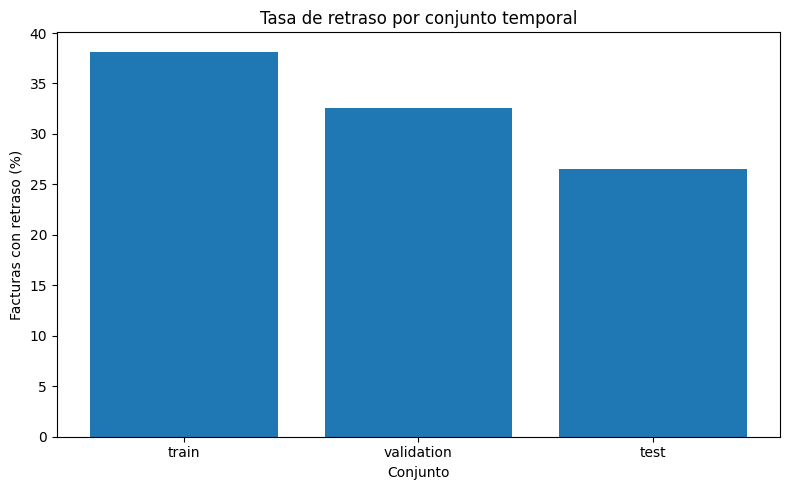

In [9]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.bar(
    split_summary["dataset"],
    split_summary["positive_rate"] * 100
)

ax.set_title(
    "Tasa de retraso por conjunto temporal"
)

ax.set_ylabel(
    "Facturas con retraso (%)"
)

ax.set_xlabel(
    "Conjunto"
)

plt.tight_layout()
plt.show()

### Separar `X` e `y`

In [10]:
X_train = train_df[
    feature_columns
].copy()

y_train = train_df[
    target_column
].copy()

X_validation = validation_df[
    feature_columns
].copy()

y_validation = validation_df[
    target_column
].copy()

X_test = test_df[
    feature_columns
].copy()

y_test = test_df[
    target_column
].copy()

print(
    X_train.shape,
    y_train.shape
)

print(
    X_validation.shape,
    y_validation.shape
)

print(
    X_test.shape,
    y_test.shape
)

(1719, 43) (1719,)
(381, 43) (381,)
(366, 43) (366,)


## 3. Baseline trivial — Dummy Classifier

Antes de entrenar un modelo supervisado es necesario establecer una referencia mínima.

Se utilizará un `DummyClassifier` que siempre predice la clase mayoritaria.

Este modelo no utiliza ninguna feature y, por tanto, no tiene capacidad predictiva.

Su función es responder a la pregunta:

> ¿Cuánto rendimiento obtendríamos simplemente prediciendo que todas las facturas se pagarán puntualmente?

Dado que la clase mayoritaria representa aproximadamente entre el 60 % y 70 % de las observaciones dependiendo del período, la accuracy del Dummy puede parecer elevada.

Por este motivo será especialmente importante observar:

- recall de la clase positiva;
- F1;
- balanced accuracy;
- ROC-AUC;
- PR-AUC.

Cualquier modelo útil deberá aportar valor claramente superior a este baseline.

### Funcion de evaluacion

In [11]:
def evaluate_classifier(
    model,
    X,
    y,
    dataset_name="dataset"
):
    """
    Evalúa un clasificador binario.

    Devuelve métricas basadas en:
    - predicción de clase;
    - probabilidad de clase positiva.
    """

    y_pred = model.predict(X)

    if hasattr(
        model,
        "predict_proba"
    ):
        y_prob = model.predict_proba(X)[:, 1]

    else:
        y_prob = None

    metrics = {
        "dataset": dataset_name,

        "accuracy": (
            accuracy_score(
                y,
                y_pred
            )
        ),

        "balanced_accuracy": (
            balanced_accuracy_score(
                y,
                y_pred
            )
        ),

        "precision": (
            precision_score(
                y,
                y_pred,
                zero_division=0
            )
        ),

        "recall": (
            recall_score(
                y,
                y_pred,
                zero_division=0
            )
        ),

        "f1": (
            f1_score(
                y,
                y_pred,
                zero_division=0
            )
        ),
        
        "f2": (
            fbeta_score(
                y,
                y_pred,
                beta=2,
                zero_division=0
            )
        ),
    }

    if y_prob is not None:

        metrics["roc_auc"] = (
            roc_auc_score(
                y,
                y_prob
            )
        )

        metrics["pr_auc"] = (
            average_precision_score(
                y,
                y_prob
            )
        )

    return pd.Series(metrics)

### Entrenar dummy classifier

In [12]:
dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(
    X_train,
    y_train
)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


### Evaluar dummy

In [13]:
dummy_train_metrics = (
    evaluate_classifier(
        dummy_model,
        X_train,
        y_train,
        "train"
    )
)

dummy_validation_metrics = (
    evaluate_classifier(
        dummy_model,
        X_validation,
        y_validation,
        "validation"
    )
)

dummy_results = pd.DataFrame([
    dummy_train_metrics,
    dummy_validation_metrics,
])

dummy_results

,dataset,accuracy,balanced_accuracy,precision,recall,f1,f2,roc_auc,pr_auc
0,train,0.618383,0.5,0.0,0.0,0.0,0.0,0.5,0.381617
1,validation,0.674541,0.5,0.0,0.0,0.0,0.0,0.5,0.325459


### Matriz de confusion

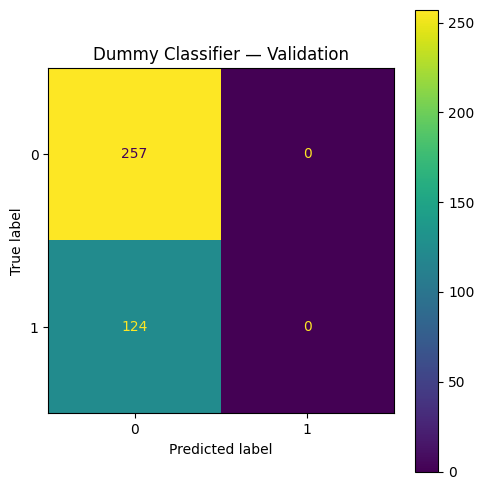

In [14]:
fig, ax = plt.subplots(
    figsize=(5, 5)
)

ConfusionMatrixDisplay.from_estimator(
    dummy_model,
    X_validation,
    y_validation,
    ax=ax,
    values_format="d"
)

ax.set_title(
    "Dummy Classifier — Validation"
)

plt.tight_layout()
plt.show()

## 4. Baseline supervisado — Regresión logística

El primer modelo supervisado será una regresión logística.

Se selecciona como baseline porque:

- es un modelo sencillo;
- produce probabilidades interpretables;
- permite establecer una referencia frente a modelos más complejos;
- funciona bien como punto de partida para clasificación binaria;
- permite analizar posteriormente el efecto de las variables.

La regresión logística requiere preparar correctamente las features.

### Variables numéricas

Se aplicará:

1. imputación de valores ausentes mediante la mediana;
2. estandarización mediante `StandardScaler`.

La imputación es necesaria porque determinadas variables históricas presentan valores ausentes estructurales cuando no existe suficiente histórico.

La mediana y los parámetros de escalado se aprenderán exclusivamente a partir del conjunto de entrenamiento.

### Variables categóricas

Se aplicará:

1. imputación de la categoría más frecuente;
2. One-Hot Encoding.

Se utilizará `handle_unknown="ignore"` para permitir que validation o test contengan categorías no observadas durante entrenamiento.

Todas estas transformaciones se incluirán dentro de un `Pipeline`, evitando contaminación entre conjuntos.

### Pipeline numerico

In [15]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
    ]
)

### Pipeline categorico

In [16]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        ),
    ]
)

### Trasndormador de columnas

In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features,
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features,
        ),
    ]
)

### Regresion logistica baseline

In [18]:
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=42,
            )
        ),
    ]
)

### Train

In [19]:
logistic_model.fit(
    X_train,
    y_train
)

print(
    "✓ Regresión logística entrenada."
)

✓ Regresión logística entrenada.


### Dummy vs Logistic

In [20]:
logistic_train_metrics = (
    evaluate_classifier(
        logistic_model,
        X_train,
        y_train,
        "train"
    )
)

logistic_validation_metrics = (
    evaluate_classifier(
        logistic_model,
        X_validation,
        y_validation,
        "validation"
    )
)

logistic_results = pd.DataFrame([
    logistic_train_metrics,
    logistic_validation_metrics,
])

logistic_results

,dataset,accuracy,balanced_accuracy,precision,recall,f1,f2,roc_auc,pr_auc
0,train,0.785922,0.763578,0.744068,0.669207,0.704655,0.682950,0.870804,0.817361
1,validation,0.837270,0.833469,0.718310,0.822581,0.766917,0.799373,0.901123,0.804192


In [21]:
baseline_comparison = pd.DataFrame([
    {
        "model": "Dummy — Most Frequent",
        **dummy_validation_metrics.to_dict()
    },
    {
        "model": "Logistic Regression",
        **logistic_validation_metrics.to_dict()
    }
])

baseline_comparison = (
    baseline_comparison
    .drop(columns="dataset")
    .set_index("model")
)

baseline_comparison

,accuracy,balanced_accuracy,precision,recall,f1,f2,roc_auc,pr_auc
model,,,,,,,,
Dummy — Most Frequent,0.674541,0.500000,0.00000,0.000000,0.000000,0.000000,0.500000,0.325459
Logistic Regression,0.837270,0.833469,0.71831,0.822581,0.766917,0.799373,0.901123,0.804192


### Classification report

In [22]:
y_validation_pred = (
    logistic_model.predict(
        X_validation
    )
)

print(
    classification_report(
        y_validation,
        y_validation_pred,
        target_names=[
            "Puntual",
            "Tardía"
        ],
        digits=3,
    )
)

              precision    recall  f1-score   support

     Puntual      0.908     0.844     0.875       257
      Tardía      0.718     0.823     0.767       124

    accuracy                          0.837       381
   macro avg      0.813     0.833     0.821       381
weighted avg      0.846     0.837     0.840       381



### Matriz de confusion

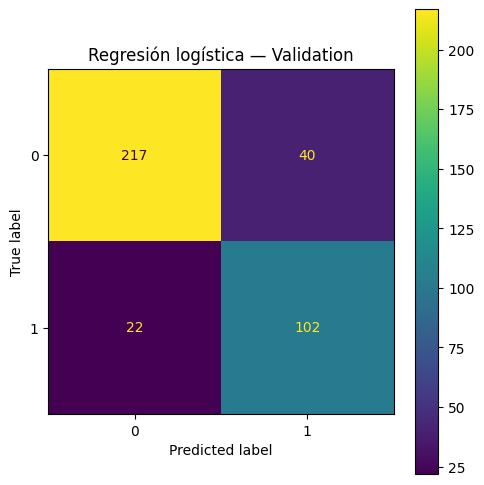

In [23]:
fig, ax = plt.subplots(
    figsize=(5, 5)
)

ConfusionMatrixDisplay.from_estimator(
    logistic_model,
    X_validation,
    y_validation,
    ax=ax,
    values_format="d",
)

ax.set_title(
    "Regresión logística — Validation"
)

plt.tight_layout()
plt.show()

In [24]:
tn, fp, fn, tp = confusion_matrix(
    y_validation,
    y_validation_pred
).ravel()

error_summary = pd.Series({
    "true_negatives": tn,
    "false_positives": fp,
    "false_negatives": fn,
    "true_positives": tp,
})

error_summary

true_negatives     217
false_positives     40
false_negatives     22
true_positives     102
dtype: int64

### Curva ROC

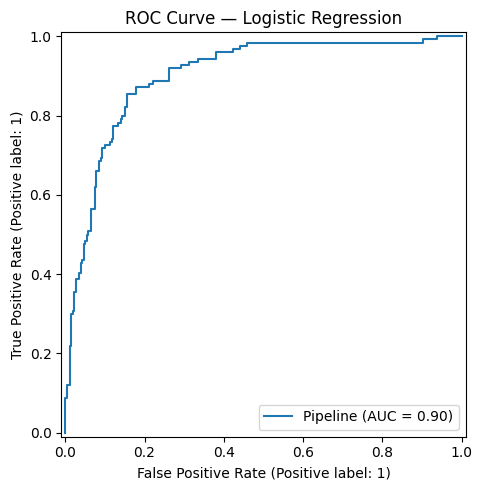

In [25]:
fig, ax = plt.subplots(
    figsize=(7, 5)
)

RocCurveDisplay.from_estimator(
    logistic_model,
    X_validation,
    y_validation,
    ax=ax,
)

ax.set_title(
    "ROC Curve — Logistic Regression"
)

plt.tight_layout()
plt.show()

### Curva Precision-Recall 

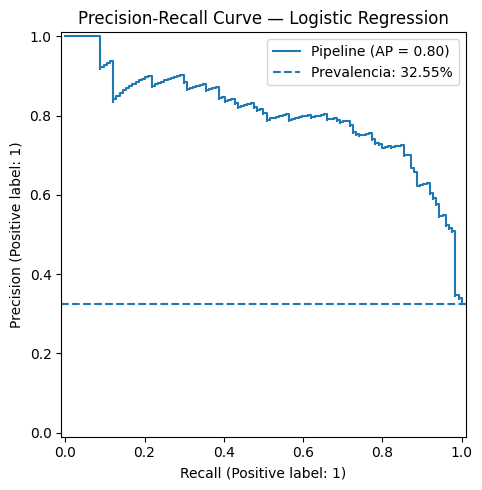

In [26]:
fig, ax = plt.subplots(
    figsize=(7, 5)
)

PrecisionRecallDisplay.from_estimator(
    logistic_model,
    X_validation,
    y_validation,
    ax=ax,
)

baseline_positive_rate = (
    y_validation.mean()
)

ax.axhline(
    baseline_positive_rate,
    linestyle="--",
    label=(
        "Prevalencia: "
        f"{baseline_positive_rate:.2%}"
    )
)

ax.set_title(
    "Precision-Recall Curve — Logistic Regression"
)

ax.legend()

plt.tight_layout()
plt.show()

## Estado del baseline inicial

La primera fase de modelado confirma que las features construidas contienen señal predictiva suficiente para superar ampliamente un modelo trivial.

Hasta este punto se han construido y comparado:

- un `DummyClassifier` como referencia mínima;
- una regresión logística como primer modelo supervisado.

Todavía no se realizarán:

- optimización de hiperparámetros;
- selección automática de features;
- SMOTE u otras técnicas de resampling;
- calibración de probabilidades;
- Random Forest;
- Gradient Boosting;
- XGBoost / LightGBM;
- SHAP;
- evaluación definitiva sobre test.

Antes de aumentar la complejidad del modelo se estudiará el efecto del threshold de clasificación utilizando únicamente el conjunto de validation.

El conjunto de test continuará completamente reservado.

Las decisiones sobre modelos, features y threshold se tomarán utilizando exclusivamente train y validation.

## Conclusiones del baseline inicial

La regresión logística supera ampliamente al Dummy Classifier en todas las métricas relevantes.

El Dummy obtiene una accuracy cercana al 67 %, pero esta cifra resulta engañosa porque clasifica todas las facturas como puntuales y no detecta ningún retraso:

- `Recall = 0`;
- `F1 = 0`;
- `Balanced Accuracy = 0.50`;
- `ROC-AUC = 0.50`.

Esto confirma que la accuracy por sí sola no es suficiente para evaluar este problema.

La regresión logística consigue sobre el conjunto de validación:

- Accuracy: 83,7 %;
- Balanced Accuracy: 83,3 %;
- Precision: 71,8 %;
- Recall: 82,3 %;
- F1: 76,7 %;
- F2: 79,9 %;
- ROC-AUC: 90,1 %;
- PR-AUC: 80,4 %.

De las 124 facturas que realmente terminaron pagándose tarde, el modelo identifica correctamente 102 y no detecta 22.

Al mismo tiempo genera 40 falsas alarmas sobre facturas que finalmente fueron pagadas de forma puntual.

Los resultados indican que las features construidas durante el feature engineering contienen una señal predictiva considerable y justifican continuar con el desarrollo del modelo.

No se observa un patrón típico de sobreajuste, ya que el rendimiento en validación no se deteriora respecto a entrenamiento. Sin embargo, existe un cambio temporal en la tasa de retraso entre train, validation y test, por lo que la capacidad de generalización temporal deberá seguir siendo evaluada cuidadosamente.

El conjunto de test permanece reservado y no se utilizará para tomar decisiones de modelado.

A partir de este punto, las siguientes iteraciones se realizarán exclusivamente utilizando train y validation.

Las métricas de clasificación anteriores corresponden al threshold estándar de 0.50. Posteriormente se estudiará si otro punto de corte permite adaptar mejor el modelo a las necesidades de negocio sin modificar su capacidad de ranking.

## 5. Análisis del umbral de clasificación

La regresión logística devuelve una probabilidad estimada de retraso para cada factura.

Por defecto, `predict()` utiliza un umbral de `0.50`:

- probabilidad < 0.50 → factura puntual;
- probabilidad >= 0.50 → factura tardía.

Sin embargo, el valor `0.50` no tiene por qué ser el umbral más adecuado desde el punto de vista empresarial.

En este proyecto, un falso negativo representa una factura que el modelo considera segura pero que finalmente paga tarde. Este error puede afectar a la previsión de caja y retrasar acciones preventivas de recobro.

Por ello interesa estudiar el compromiso entre:

- **Recall**: proporción de retrasos reales detectados;
- **Precision**: proporción de alertas que realmente corresponden a retrasos;
- **F1**: equilibrio entre Precision y Recall;
- **F2**: equilibrio que da mayor importancia al Recall.

El análisis del threshold se realizará exclusivamente sobre el conjunto de validación.

El conjunto de test permanecerá completamente reservado.

### Probabilidades de validation

In [27]:
y_validation_prob = (
    logistic_model
    .predict_proba(X_validation)[:, 1]
)

probability_summary = pd.Series({
    "min_probability": y_validation_prob.min(),
    "mean_probability": y_validation_prob.mean(),
    "median_probability": np.median(y_validation_prob),
    "max_probability": y_validation_prob.max(),
})

probability_summary

min_probability       0.001805
mean_probability      0.399348
median_probability    0.302391
max_probability       0.999195
dtype: float64

### Distribucion de probabilidades

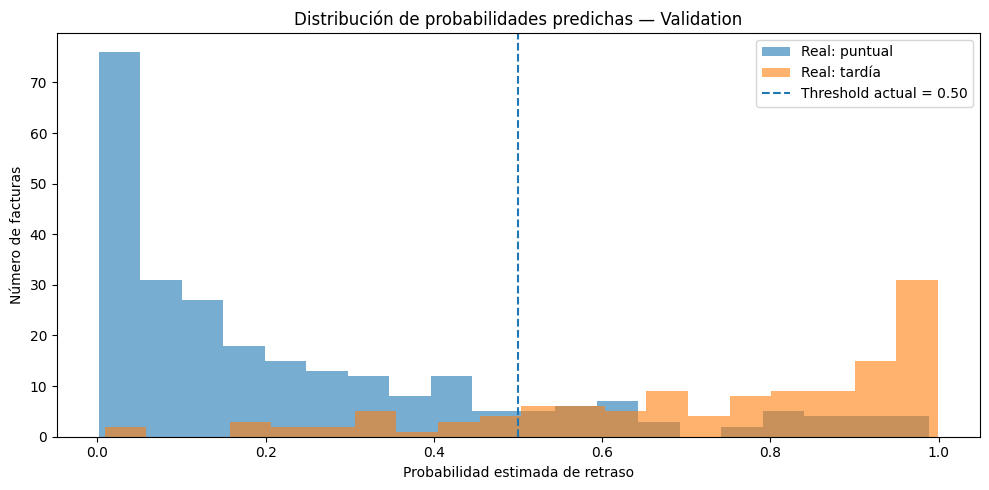

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    y_validation_prob[
        y_validation.to_numpy() == 0
    ],
    bins=20,
    alpha=0.6,
    label="Real: puntual"
)

ax.hist(
    y_validation_prob[
        y_validation.to_numpy() == 1
    ],
    bins=20,
    alpha=0.6,
    label="Real: tardía"
)

ax.axvline(
    0.50,
    linestyle="--",
    label="Threshold actual = 0.50"
)

ax.set_title(
    "Distribución de probabilidades predichas — Validation"
)

ax.set_xlabel(
    "Probabilidad estimada de retraso"
)

ax.set_ylabel(
    "Número de facturas"
)

ax.legend()

plt.tight_layout()
plt.show()

### Funcion para evaluar thresholds

In [29]:
def evaluate_threshold(
    y_true,
    y_prob,
    threshold
):
    """
    Calcula métricas de clasificación para
    un threshold determinado.
    """

    y_pred = (
        y_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    return {
        "threshold": threshold,

        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "f2": fbeta_score(
            y_true,
            y_pred,
            beta=2,
            zero_division=0
        ),

        "balanced_accuracy": (
            balanced_accuracy_score(
                y_true,
                y_pred
            )
        ),

        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
    }

### Evaluar multiples thresholds

In [30]:
thresholds = np.arange(
    0.10,
    0.91,
    0.02
)

threshold_results = pd.DataFrame([
    evaluate_threshold(
        y_validation,
        y_validation_prob,
        threshold
    )
    for threshold in thresholds
])

display(threshold_results.head())
threshold_results.tail()

,threshold,precision,recall,f1,f2,balanced_accuracy,true_negatives,false_positives,false_negatives,true_positives
0,0.10,0.448529,0.983871,0.616162,0.794271,0.700107,107,150,2,122
1,0.12,0.471042,0.983871,0.637076,0.807947,0.725399,120,137,2,122
2,0.14,0.489960,0.983871,0.654155,0.818792,0.744854,130,127,2,122
3,0.16,0.502058,0.983871,0.664850,0.825440,0.756527,136,121,2,122
4,0.18,0.517094,0.975806,0.675978,0.828767,0.768059,144,113,3,121


,threshold,precision,recall,f1,f2,balanced_accuracy,true_negatives,false_positives,false_negatives,true_positives
36,0.82,0.807692,0.508065,0.623762,0.548780,0.724849,242,15,61,63
37,0.84,0.828571,0.467742,0.597938,0.512367,0.710525,245,12,66,58
38,0.86,0.828125,0.427419,0.563830,0.473214,0.692309,246,11,71,53
39,0.88,0.844828,0.395161,0.538462,0.442238,0.680071,248,9,75,49
40,0.90,0.867925,0.370968,0.519774,0.418944,0.671865,250,7,78,46


### Comparativa de metricas segun threshold

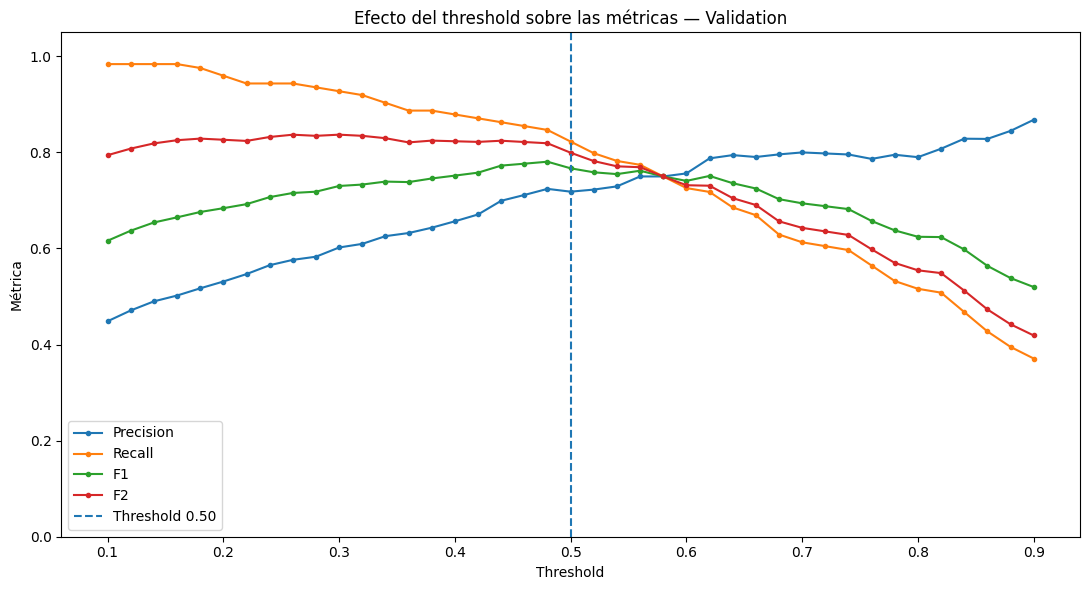

In [31]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    marker="o",
    markersize=3,
    label="Precision"
)

ax.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    marker="o",
    markersize=3,
    label="Recall"
)

ax.plot(
    threshold_results["threshold"],
    threshold_results["f1"],
    marker="o",
    markersize=3,
    label="F1"
)

ax.plot(
    threshold_results["threshold"],
    threshold_results["f2"],
    marker="o",
    markersize=3,
    label="F2"
)

ax.axvline(
    0.50,
    linestyle="--",
    label="Threshold 0.50"
)

ax.set_title(
    "Efecto del threshold sobre las métricas — Validation"
)

ax.set_xlabel(
    "Threshold"
)

ax.set_ylabel(
    "Métrica"
)

ax.set_ylim(
    0,
    1.05
)

ax.legend()

plt.tight_layout()
plt.show()

### Maximizar threshold con F2

In [32]:
best_f2_row = (
    threshold_results
    .loc[
        threshold_results["f2"].idxmax()
    ]
)

display(best_f2_row)

best_f2_threshold = (
    best_f2_row["threshold"]
)

print(
    f"Threshold con mayor F2: "
    f"{best_f2_threshold:.2f}"
)

print(
    f"Precision: "
    f"{best_f2_row['precision']:.3f}"
)

print(
    f"Recall: "
    f"{best_f2_row['recall']:.3f}"
)

print(
    f"F1: "
    f"{best_f2_row['f1']:.3f}"
)

print(
    f"F2: "
    f"{best_f2_row['f2']:.3f}"
)

threshold              0.300000
precision              0.602094
recall                 0.927419
f1                     0.730159
f2                     0.836972
balanced_accuracy      0.815850
true_negatives       181.000000
false_positives       76.000000
false_negatives        9.000000
true_positives       115.000000
Name: 10, dtype: float64

Threshold con mayor F2: 0.30
Precision: 0.602
Recall: 0.927
F1: 0.730
F2: 0.837


### Threshold orientado al Recall >= 90%

In [33]:
recall_target = 0.90

recall_candidates = (
    threshold_results[
        threshold_results["recall"]
        >= recall_target
    ]
)

if not recall_candidates.empty:

    recall_90_row = (
        recall_candidates
        .sort_values(
            "threshold",
            ascending=False
        )
        .iloc[0]
    )

    display(
        recall_90_row.to_frame(
            name="Recall >= 90%"
        )
    )

else:

    print(
        "No existe ningún threshold "
        "con Recall >= 90 %."
    )

,Recall >= 90%
threshold,0.340000
precision,0.625698
recall,0.903226
f1,0.739274
f2,0.829630
balanced_accuracy,0.821263
true_negatives,190.000000
false_positives,67.000000
false_negatives,12.000000
true_positives,112.000000


### Comparar thresholds

In [34]:
default_row = evaluate_threshold(
    y_validation,
    y_validation_prob,
    0.50
)

comparison_rows = [
    {
        "strategy": "Default 0.50",
        **default_row
    },
    {
        "strategy": "Max F2",
        **best_f2_row.to_dict()
    },
]

if not recall_candidates.empty:

    comparison_rows.append({
        "strategy": "Recall >= 90%",
        **recall_90_row.to_dict()
    })

threshold_comparison = pd.DataFrame(
    comparison_rows
)

threshold_comparison[
    [
        "strategy",
        "threshold",
        "precision",
        "recall",
        "f1",
        "f2",
        "balanced_accuracy",
        "false_positives",
        "false_negatives",
        "true_positives",
    ]
]

,strategy,threshold,precision,recall,f1,f2,balanced_accuracy,false_positives,false_negatives,true_positives
0,Default 0.50,0.50,0.718310,0.822581,0.766917,0.799373,0.833469,40.0,22.0,102.0
1,Max F2,0.30,0.602094,0.927419,0.730159,0.836972,0.815850,76.0,9.0,115.0
2,Recall >= 90%,0.34,0.625698,0.903226,0.739274,0.829630,0.821263,67.0,12.0,112.0


### Interpretación empresarial del threshold

La selección del threshold determina cuántas facturas serán marcadas como potencialmente problemáticas.

Reducir el threshold aumenta normalmente el número de retrasos detectados, pero también genera más falsas alarmas.

Esto implica un compromiso empresarial:

- un threshold bajo prioriza la prevención y reduce los retrasos no detectados;
- un threshold alto reduce el número de alertas, pero aumenta el riesgo de no anticipar determinados retrasos.

La elección definitiva debería depender de factores como:

- capacidad del equipo de recobro;
- coste de revisar una falsa alarma;
- importe económico de las facturas;
- coste esperado de un retraso no anticipado;
- necesidades de planificación de tesorería.

En ausencia de una función de costes empresarial explícita, se utilizará F2 como referencia técnica porque otorga mayor peso al Recall, pero no se asumirá automáticamente que su máximo representa el threshold empresarial definitivo.

### Matriz F2

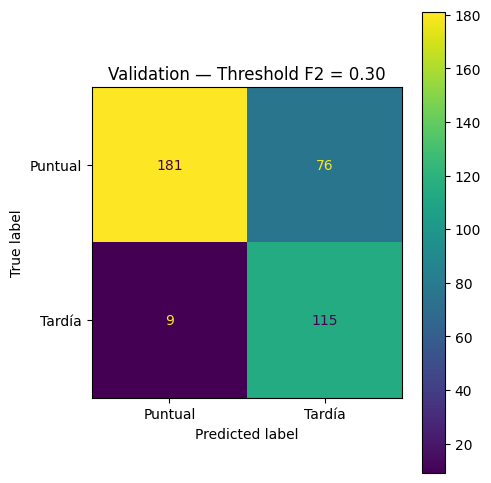

In [35]:
y_validation_pred_f2 = (
    y_validation_prob
    >= best_f2_threshold
).astype(int)

cm_f2 = confusion_matrix(
    y_validation,
    y_validation_pred_f2
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_f2,
    display_labels=[
        "Puntual",
        "Tardía"
    ]
)

fig, ax = plt.subplots(
    figsize=(5, 5)
)

disp.plot(
    ax=ax,
    values_format="d"
)

ax.set_title(
    f"Validation — Threshold F2 = "
    f"{best_f2_threshold:.2f}"
)

plt.tight_layout()
plt.show()

### Numero de alertas segun estrategia

In [36]:
alert_summary = []

for _, row in threshold_comparison.iterrows():

    threshold = row["threshold"]

    predicted_alerts = (
        y_validation_prob
        >= threshold
    ).sum()

    alert_summary.append({
        "strategy": row["strategy"],
        "threshold": threshold,
        "alerts": predicted_alerts,
        "alerts_pct": (
            predicted_alerts
            / len(y_validation)
            * 100
        ),
        "false_positives": row["false_positives"],
        "false_negatives": row["false_negatives"],
    })

alert_summary = pd.DataFrame(
    alert_summary
)

alert_summary

,strategy,threshold,alerts,alerts_pct,false_positives,false_negatives
0,Default 0.50,0.50,142,37.270341,40.0,22.0
1,Max F2,0.30,191,50.131234,76.0,9.0
2,Recall >= 90%,0.34,179,46.981627,67.0,12.0


### Distribucion de riesgo por factura

In [37]:
validation_predictions = (
    validation_df[
        [
            "invoice_id",
            "customer_id",
            "invoice_date",
            "late_payment"
        ]
    ]
    .copy()
)

validation_predictions[
    "predicted_risk"
] = y_validation_prob

validation_predictions[
    "prediction_050"
] = (
    validation_predictions[
        "predicted_risk"
    ]
    >= 0.50
).astype(int)

validation_predictions[
    "prediction_f2"
] = (
    validation_predictions[
        "predicted_risk"
    ]
    >= best_f2_threshold
).astype(int)

validation_predictions.sort_values(
    "predicted_risk",
    ascending=False
).head(20)

,invoice_id,customer_id,invoice_date,late_payment,predicted_risk,prediction_050,prediction_f2
1819,6685297571,4460-ZXNDN,2013-05-29,1,0.999195,1,1
2081,9614769756,8102-ABPKQ,2013-08-14,1,0.997541,1,1
2069,3374535086,8102-ABPKQ,2013-08-12,1,0.997494,1,1
1835,7403439811,0688-XNJRO,2013-06-02,1,0.997148,1,1
1983,5963438295,0688-XNJRO,2013-07-16,1,0.996490,1,1
1869,5353996897,5148-SYKLB,2013-06-11,1,0.994585,1,1
2030,8912612689,2621-XCLEH,2013-07-28,1,0.993755,1,1
1794,572625167,4460-ZXNDN,2013-05-24,1,0.992925,1,1
1947,5288556291,8102-ABPKQ,2013-07-05,1,0.991297,1,1
1965,4668608174,9181-HEKGV,2013-07-11,1,0.990646,1,1


## Conclusiones del análisis de threshold

El análisis confirma que el threshold estándar de 0.50 no representa necesariamente el punto de operación más adecuado para el problema.

Con `threshold = 0.50`, la regresión logística presenta:

- Precision = 71,8 %;
- Recall = 82,3 %;
- F2 = 79,9 %;
- 40 falsas alarmas;
- 22 retrasos no detectados;
- 142 facturas marcadas como riesgo, equivalentes al 37,3 % del conjunto de validation.

Al reducir el threshold aumenta la capacidad de detectar retrasos, aunque también aumenta el número de falsas alarmas.

### Threshold que maximiza F2

El máximo F2 sobre validation se obtiene aproximadamente con:

`threshold = 0.30`

Con este punto de corte:

- Precision = 60,2 %;
- Recall = 92,7 %;
- F2 = 83,7 %;
- se detectan 115 de las 124 facturas tardías;
- únicamente 9 retrasos quedan sin detectar;
- se generan 76 falsas alarmas;
- el modelo marcaría aproximadamente el 50,1 % de las facturas para revisión.

Respecto al threshold 0.50, se consiguen detectar 13 retrasos adicionales, pero a cambio se generan 36 falsas alarmas adicionales.

### Escenario con Recall mínimo del 90 %

También se ha estudiado el threshold más alto capaz de mantener un Recall igual o superior al 90 %.

El resultado es aproximadamente:

`threshold = 0.34`

Con este punto de corte:

- Precision = 62,6 %;
- Recall = 90,3 %;
- F2 = 83,0 %;
- se detectan 112 de las 124 facturas tardías;
- quedan 12 retrasos sin detectar;
- se generan 67 falsas alarmas;
- se marcaría aproximadamente el 47,0 % de las facturas para revisión.

Este escenario proporciona un compromiso intermedio entre el threshold estándar y el threshold que maximiza F2.

### Decisión provisional

Los resultados anteriores corresponden al modelo completo (`D_full`) con las 43 features disponibles.

El threshold de 0.30 maximiza F2 para esta configuración y el threshold de 0.34 permite mantener un Recall superior al 90 % utilizando menos alertas.

Sin embargo, estos thresholds no se considerarán definitivos.

La selección del punto de corte depende también del conjunto de features y del modelo finalmente seleccionado. Por este motivo, el análisis de threshold realizado en esta sección debe interpretarse como una primera evaluación operativa del modelo completo.

Después de comparar los diferentes bloques de features se volverá a calcular el threshold sobre el modelo seleccionado.

El conjunto de test continúa reservado y no se utilizará para tomar decisiones sobre:

- features;
- algoritmo;
- preprocesamiento;
- threshold.

## 6. Ablación de grupos de features

Antes de aumentar la complejidad del algoritmo se analizará qué grupos de variables son responsables de la capacidad predictiva observada.

Todos los experimentos utilizarán:

- el mismo conjunto de entrenamiento;
- el mismo conjunto de validation;
- la misma regresión logística;
- el mismo pipeline de preprocesamiento;
- los mismos hiperparámetros.

La única diferencia entre modelos será el conjunto de features utilizado.

Se construirán cuatro versiones incrementales.

### Modelo A — Factura actual

Utiliza únicamente información básica de la factura:

- importe;
- modalidad de facturación;
- país del cliente.

Este modelo permite establecer cuánto puede predecirse sin utilizar histórico ni evolución temporal.

### Modelo B — Factura actual + contexto temporal

Añade variables relacionadas con la fecha de emisión.

Este bloque es especialmente importante porque durante el EDA se observó una reducción de la tasa de retraso a lo largo del histórico.

Permitirá comprobar cuánto rendimiento procede de esta evolución temporal.

### Modelo C — + Histórico del cliente

Añade comportamiento comercial y de pago conocido:

- número de operaciones anteriores;
- tasa histórica de retraso;
- retraso medio y reciente;
- importe habitual del cliente;
- disponibilidad de histórico.

Este experimento permite cuantificar el valor predictivo aportado por conocer cómo se ha comportado anteriormente cada cliente.

### Modelo D — Modelo completo

Añade finalmente información sobre la situación pendiente del cliente en el momento de emisión:

- facturas todavía abiertas;
- deuda ya vencida;
- importes pendientes;
- antigüedad de la deuda vencida.

Este modelo corresponde al conjunto completo de features construido durante el feature engineering.

## Criterio de comparación

Para comparar los bloques se prestará especial atención a métricas independientes del threshold:

- ROC-AUC;
- PR-AUC.

Esto permite evaluar la capacidad de discriminación de cada conjunto de variables sin que la comparación dependa de haber elegido todavía un punto de corte específico.

También se mostrarán Recall, Precision, F1 y F2 con threshold 0.50 como métricas complementarias.

### Definir bloques de features

In [38]:
invoice_features = [
    "invoice_amount",
    "log_invoice_amount",
    "paperless_bill",
    "country_code",
]

temporal_features = [
    "invoice_year",
    "invoice_month",
    "invoice_quarter",
    "invoice_weekday",
    "is_month_start",
    "is_month_end",
    "days_since_dataset_start",
]

customer_history_features = [
    # Histórico comercial
    "previous_issued_count",
    "previous_avg_invoice_amount",
    "previous_median_invoice_amount",
    "days_since_previous_invoice",

    # Histórico de pagos conocido
    "previous_settled_count",
    "previous_late_count",
    "previous_late_rate",
    "previous_avg_delay",
    "previous_median_delay",
    "previous_max_delay",
    "last_payment_delay",
    "days_since_last_payment",

    # Comportamiento reciente
    "last_3_late_rate",
    "last_3_avg_delay",
    "last_5_late_rate",
    "last_5_avg_delay",

    # Importe relativo al histórico
    "amount_vs_previous_avg",
    "amount_vs_previous_median",
    "amount_diff_vs_previous_avg",

    # Disponibilidad de histórico
    "is_new_customer",
    "has_payment_history",
    "has_3_payment_history",
    "has_5_payment_history",
]

exposure_features = [
    "open_invoice_count_at_issue",
    "open_invoice_amount_at_issue",
    "overdue_invoice_count_at_issue",
    "overdue_amount_at_issue",
    "oldest_overdue_days_at_issue",

    "open_amount_vs_current_invoice",
    "overdue_amount_vs_current_invoice",

    "has_open_invoices",
    "has_overdue_invoices",
]

### Construir modelos conceptuales

In [39]:
feature_groups = {
    "A_invoice": (
        invoice_features
    ),

    "B_invoice_time": (
        invoice_features
        + temporal_features
    ),

    "C_invoice_time_history": (
        invoice_features
        + temporal_features
        + customer_history_features
    ),

    "D_full": (
        invoice_features
        + temporal_features
        + customer_history_features
        + exposure_features
    ),
}

for name, features in feature_groups.items():

    print(
        f"{name:25s}"
        f"{len(features):3d} features"
    )

A_invoice                  4 features
B_invoice_time            11 features
C_invoice_time_history    34 features
D_full                    43 features


### Validacion de grupos

In [40]:
for name, features in feature_groups.items():

    missing = [
        col
        for col in features
        if col not in feature_columns
    ]

    assert not missing, (
        f"{name} contiene columnas "
        f"no disponibles: {missing}"
    )

print(
    "✓ Todos los grupos contienen "
    "features válidas."
)

assert (
    set(feature_groups["D_full"])
    == set(feature_columns)
)

print(
    "✓ El modelo D contiene exactamente "
    "las 43 features del modelo completo."
)

✓ Todos los grupos contienen features válidas.
✓ El modelo D contiene exactamente las 43 features del modelo completo.


### Pipeline común para la ablación

Para que la comparación sea válida, todos los modelos utilizarán exactamente el mismo procedimiento de entrenamiento.

Para cada grupo de features se construirá un pipeline que:

1. identifica variables numéricas y categóricas;
2. imputa variables numéricas mediante la mediana;
3. estandariza las variables numéricas;
4. imputa variables categóricas mediante la categoría más frecuente;
5. aplica One-Hot Encoding;
6. entrena una regresión logística con los mismos hiperparámetros.

De esta forma, cualquier diferencia de rendimiento puede atribuirse principalmente a la información añadida por cada bloque de features y no a cambios en el algoritmo o en el preprocesamiento.

### Funcion del pipeline

In [41]:
categorical_candidates = [
    "paperless_bill",
    "country_code",
    "invoice_month",
    "invoice_quarter",
    "invoice_weekday",
]

def build_logistic_pipeline(features):
    """
    Construye una regresión logística con
    preprocesamiento adaptado al conjunto
    de features recibido.
    """

    categorical = [
        col
        for col in categorical_candidates
        if col in features
    ]

    numeric = [
        col
        for col in features
        if col not in categorical
    ]

    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "scaler",
                StandardScaler()
            ),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore"
                )
            ),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                numeric
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical
            ),
        ]
    )

    model = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "classifier",
                LogisticRegression(
                    max_iter=2000,
                    random_state=42,
                )
            ),
        ]
    )

    return model

### Entrenar los modelos

In [47]:
ablation_models = {}
ablation_results = []

for name, features in feature_groups.items():

    model = build_logistic_pipeline(
        features
    )

    model.fit(
        train_df[features],
        y_train
    )

    metrics = evaluate_classifier(
        model,
        validation_df[features],
        y_validation,
        dataset_name="validation"
    )

    result = {
        "model": name,
        "n_features": len(features),
        **metrics.to_dict(),
    }

    ablation_results.append(
        result
    )

    ablation_models[name] = model

ablation_results = pd.DataFrame(
ablation_results
)

ablation_results

ablation_results.columns.tolist()

ablation_comparison = (
    ablation_results[
        [
            "model",
            "n_features",
            "accuracy",
            "balanced_accuracy",
            "precision",
            "recall",
            "f1",
            "f2",
            "roc_auc",
            "pr_auc",
        ]
    ]
    .set_index("model")
)

display(
    ablation_comparison
)

ablation_gain = (
    ablation_results[
        [
            "model",
            "n_features",
            "roc_auc",
            "pr_auc",
        ]
    ]
    .copy()
)

ablation_gain[
    "delta_roc_auc"
] = (
    ablation_gain["roc_auc"]
    .diff()
)

ablation_gain[
    "delta_pr_auc"
] = (
    ablation_gain["pr_auc"]
    .diff()
)

display(
    ablation_gain
)

,n_features,accuracy,balanced_accuracy,precision,recall,f1,f2,roc_auc,pr_auc
model,,,,,,,,,
A_invoice,4,0.685039,0.532823,0.600000,0.096774,0.166667,0.116279,0.653791,0.512945
B_invoice_time,11,0.690289,0.538801,0.650000,0.104839,0.180556,0.125969,0.644942,0.498936
C_invoice_time_history,34,0.834646,0.833611,0.710345,0.830645,0.765799,0.803432,0.904387,0.801798
D_full,43,0.837270,0.833469,0.718310,0.822581,0.766917,0.799373,0.901123,0.804192


,model,n_features,roc_auc,pr_auc,delta_roc_auc,delta_pr_auc
0,A_invoice,4,0.653791,0.512945,NaN,NaN
1,B_invoice_time,11,0.644942,0.498936,-0.008849,-0.014009
2,C_invoice_time_history,34,0.904387,0.801798,0.259445,0.302862
3,D_full,43,0.901123,0.804192,-0.003263,0.002394


### Interpretación de la ablación

El análisis incremental permitirá responder varias preguntas relevantes.

#### Modelo A → Modelo B

La diferencia mide cuánto valor aporta conocer el momento temporal en el que se emite la factura.

Una mejora elevada indicaría que parte importante de la predicción procede del cambio temporal observado durante el EDA.

#### Modelo B → Modelo C

Esta es una de las comparaciones más importantes del proyecto.

Mide cuánto valor adicional aporta conocer el comportamiento histórico del cliente respecto a utilizar únicamente información de la factura y del momento temporal.

Una mejora clara reforzaría la hipótesis empresarial de que el histórico de pagos constituye una señal relevante para anticipar nuevos retrasos.

#### Modelo C → Modelo D

Mide el valor adicional de conocer la exposición actual del cliente:

- facturas abiertas;
- deuda vencida;
- importes pendientes;
- antigüedad de la deuda.

Una mejora significativa indicaría que no solo importa cómo ha pagado históricamente el cliente, sino también cuál es su situación pendiente en el momento en el que se emite una nueva factura.

### Visualizacion PR-AUC

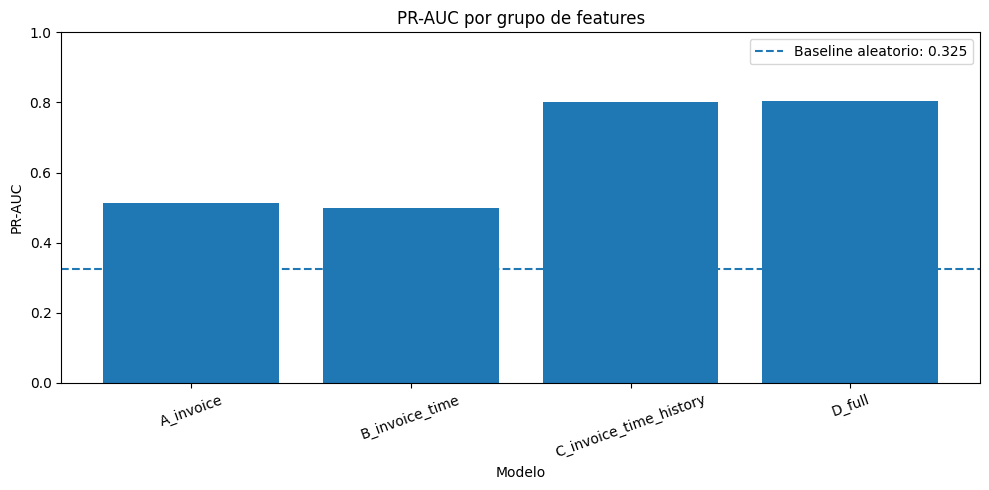

In [43]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.bar(
    ablation_results["model"],
    ablation_results["pr_auc"]
)

ax.axhline(
    y_validation.mean(),
    linestyle="--",
    label=(
        "Baseline aleatorio: "
        f"{y_validation.mean():.3f}"
    )
)

ax.set_title(
    "PR-AUC por grupo de features"
)

ax.set_xlabel(
    "Modelo"
)

ax.set_ylabel(
    "PR-AUC"
)

ax.set_ylim(
    0,
    1
)

ax.legend()

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Visualizacion ROC-AUC

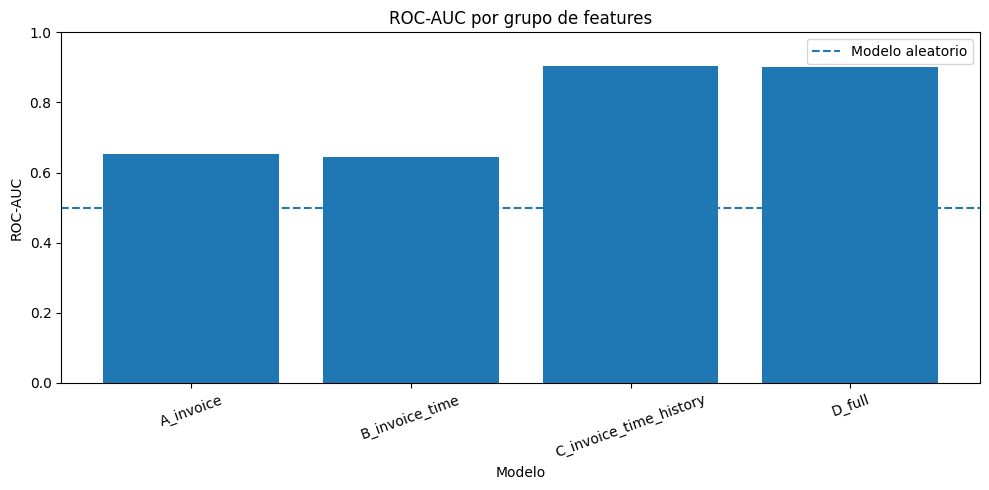

In [44]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.bar(
    ablation_results["model"],
    ablation_results["roc_auc"]
)

ax.axhline(
    0.50,
    linestyle="--",
    label="Modelo aleatorio"
)

ax.set_title(
    "ROC-AUC por grupo de features"
)

ax.set_xlabel(
    "Modelo"
)

ax.set_ylabel(
    "ROC-AUC"
)

ax.set_ylim(
    0,
    1
)

ax.legend()

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Recall vs Precision

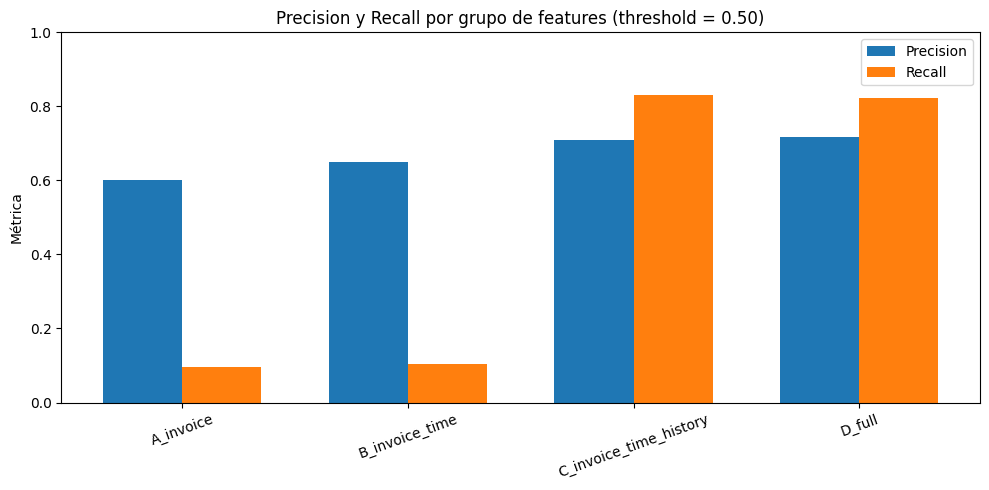

In [45]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

x = np.arange(
    len(ablation_results)
)

width = 0.35

ax.bar(
    x - width / 2,
    ablation_results["precision"],
    width,
    label="Precision"
)

ax.bar(
    x + width / 2,
    ablation_results["recall"],
    width,
    label="Recall"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    ablation_results["model"],
    rotation=20
)

ax.set_ylim(
    0,
    1
)

ax.set_title(
    "Precision y Recall por grupo de features "
    "(threshold = 0.50)"
)

ax.set_ylabel(
    "Métrica"
)

ax.legend()

plt.tight_layout()
plt.show()

### Mejor F2

In [46]:
ablation_threshold_results = []

for name, features in feature_groups.items():

    model = ablation_models[name]

    probabilities = (
        model
        .predict_proba(
            validation_df[features]
        )[:, 1]
    )

    model_thresholds = pd.DataFrame([
        evaluate_threshold(
            y_validation,
            probabilities,
            threshold
        )
        for threshold in thresholds
    ])

    best_row = (
        model_thresholds
        .loc[
            model_thresholds["f2"]
            .idxmax()
        ]
    )

    ablation_threshold_results.append({
        "model": name,
        "best_threshold": (
            best_row["threshold"]
        ),
        "precision": (
            best_row["precision"]
        ),
        "recall": (
            best_row["recall"]
        ),
        "f1": (
            best_row["f1"]
        ),
        "f2": (
            best_row["f2"]
        ),
        "false_positives": (
            best_row["false_positives"]
        ),
        "false_negatives": (
            best_row["false_negatives"]
        ),
    })
    
ablation_threshold_comparison = (
    pd.DataFrame(
        ablation_threshold_results
    )
)

ablation_threshold_comparison

,model,best_threshold,precision,recall,f1,f2,false_positives,false_negatives
0,A_invoice,0.20,0.356932,0.975806,0.522678,0.724551,218.0,3.0
1,B_invoice_time,0.14,0.327177,1.000000,0.493042,0.708571,255.0,0.0
2,C_invoice_time_history,0.32,0.607330,0.935484,0.736508,0.844250,75.0,8.0
3,D_full,0.30,0.602094,0.927419,0.730159,0.836972,76.0,9.0


## Criterio para seleccionar el conjunto de features

La selección del conjunto de variables no se realizará únicamente buscando el modelo con la métrica más alta.

Se tendrán en cuenta:

1. **PR-AUC y ROC-AUC**
   - capacidad de discriminación independiente del threshold.

2. **Mejora incremental**
   - cuánto valor aporta cada nuevo bloque de información.

3. **Recall, Precision y F2**
   - comportamiento operativo de las predicciones.

4. **Complejidad**
   - si añadir numerosas variables produce una mejora mínima, puede ser preferible utilizar un modelo más sencillo.

5. **Interpretabilidad empresarial**
   - interesa conocer si el histórico de pagos y la exposición pendiente aportan valor real frente a utilizar únicamente características básicas de la factura.

El conjunto de test permanecerá reservado durante todo este proceso.

# Conclusiones de la ablación de features

El análisis de ablación permite identificar qué grupos de información son responsables de la capacidad predictiva observada en la regresión logística.

## Modelo A — Características de la factura

El modelo que utiliza únicamente:

- importe;
- modalidad de facturación;
- país;

obtiene:

- ROC-AUC = 0,654;
- PR-AUC = 0,513.

Estas variables contienen cierta señal predictiva, pero su capacidad de discriminación es limitada.

## Modelo B — Incorporación del contexto temporal

Al añadir las variables temporales, el rendimiento no mejora:

- ROC-AUC pasa de 0,654 a 0,645;
- PR-AUC pasa de 0,513 a 0,499.

Por tanto, las variables temporales por sí solas no explican el elevado rendimiento obtenido por el modelo completo.

Este resultado es especialmente relevante porque durante el EDA se observó una reducción de la tasa de retraso a lo largo del tiempo. La ablación muestra que la capacidad predictiva del modelo no procede únicamente de aprender esa tendencia temporal.

## Modelo C — Incorporación del histórico del cliente

La mayor mejora aparece al incorporar las variables relacionadas con el comportamiento histórico del cliente.

El modelo pasa de:

- ROC-AUC = 0,645 a ROC-AUC = 0,904;
- PR-AUC = 0,499 a PR-AUC = 0,802.

Esto supone una mejora aproximada de:

- +0,259 en ROC-AUC;
- +0,303 en PR-AUC.

El resultado confirma una de las principales hipótesis del proyecto: el comportamiento histórico de pago de un cliente constituye una fuente de información muy relevante para anticipar el riesgo de retraso de nuevas facturas.

Variables relacionadas con:

- frecuencia histórica de retraso;
- días medios de retraso;
- comportamiento reciente;
- número de pagos conocidos;
- importe habitual del cliente;

aportan una capacidad predictiva muy superior a utilizar únicamente las características de la factura.

## Modelo D — Incorporación de exposición pendiente

El modelo completo añade nueve variables relacionadas con:

- facturas abiertas;
- importe pendiente;
- deuda vencida;
- antigüedad de la deuda;
- ratios de exposición.

Sin embargo, la mejora respecto al Modelo C es mínima.

El ROC-AUC disminuye ligeramente:

`0,904 → 0,901`

mientras que PR-AUC aumenta únicamente:

`0,802 → 0,804`

La mejora de PR-AUC es de aproximadamente 0,0024 y no parece justificar por sí sola el incremento de complejidad.

## Comparación utilizando F2

La misma conclusión aparece al optimizar el threshold sobre validation.

El Modelo C alcanza aproximadamente:

- threshold = 0,32;
- Precision = 60,7 %;
- Recall = 93,5 %;
- F2 = 84,4 %;
- 75 falsas alarmas;
- 8 retrasos no detectados.

El Modelo D obtiene:

- threshold = 0,30;
- Precision = 60,2 %;
- Recall = 92,7 %;
- F2 = 83,7 %;
- 76 falsas alarmas;
- 9 retrasos no detectados.

Por tanto, el Modelo C consigue un resultado ligeramente superior utilizando nueve features menos.

## Selección provisional de features

Se selecciona provisionalmente el **Modelo C (`invoice + time + customer history`)** como conjunto de features para las siguientes iteraciones.

Esta decisión se basa en:

- mayor ROC-AUC que el modelo completo;
- PR-AUC prácticamente equivalente;
- mayor F2;
- mayor Recall;
- menor número de falsos positivos;
- menor número de falsos negativos;
- menor complejidad.

Las variables de exposición no se consideran inútiles. Su aportación puede ser diferente en modelos no lineales y podrían recuperarse posteriormente si algoritmos basados en árboles muestran que contienen interacciones relevantes.

Sin embargo, para el baseline de regresión logística no aportan una mejora suficiente como para justificar su inclusión.

## Conclusión empresarial

El resultado más relevante de la ablación es que la capacidad predictiva del sistema procede principalmente del **histórico de comportamiento de pago del cliente**.

Esto respalda la utilidad empresarial del proyecto: conocer cómo ha pagado anteriormente un cliente permite anticipar con mucha mayor precisión el riesgo de que una nueva factura sea pagada fuera de plazo.

## 7. Reconstrucción del modelo seleccionado — Modelo C

El análisis de ablación ha mostrado que la mayor ganancia predictiva aparece al incorporar el histórico de comportamiento del cliente.

El Modelo C utiliza:

- características de la factura actual;
- contexto temporal;
- histórico comercial del cliente;
- histórico de pagos conocido;
- comportamiento reciente;
- variables relativas al importe;
- indicadores de disponibilidad de histórico.

No incorpora las variables relacionadas con exposición pendiente y deuda vencida.

Esta configuración contiene 34 features y presenta un rendimiento ligeramente superior al modelo completo en ROC-AUC, Recall y F2, utilizando además nueve variables menos.

A partir de este punto, la regresión logística basada en el Modelo C se considerará el baseline supervisado seleccionado.

Se volverá a entrenar de forma explícita para:

1. comprobar sus métricas de train y validation;
2. recalcular el threshold más adecuado;
3. analizar sus errores;
4. estudiar posteriormente sus coeficientes e interpretabilidad.

El conjunto de test continuará completamente reservado.

### Seleccion de features del Modelo C

In [48]:
feature_groups

model_c_features = (
    feature_groups[
        "C_invoice_time_history"
    ]
)

print(
    f"Número de features del Modelo C: "
    f"{len(model_c_features)}"
)

model_c_features

Número de features del Modelo C: 34


['invoice_amount',
 'log_invoice_amount',
 'paperless_bill',
 'country_code',
 'invoice_year',
 'invoice_month',
 'invoice_quarter',
 'invoice_weekday',
 'is_month_start',
 'is_month_end',
 'days_since_dataset_start',
 'previous_issued_count',
 'previous_avg_invoice_amount',
 'previous_median_invoice_amount',
 'days_since_previous_invoice',
 'previous_settled_count',
 'previous_late_count',
 'previous_late_rate',
 'previous_avg_delay',
 'previous_median_delay',
 'previous_max_delay',
 'last_payment_delay',
 'days_since_last_payment',
 'last_3_late_rate',
 'last_3_avg_delay',
 'last_5_late_rate',
 'last_5_avg_delay',
 'amount_vs_previous_avg',
 'amount_vs_previous_median',
 'amount_diff_vs_previous_avg',
 'is_new_customer',
 'has_payment_history',
 'has_3_payment_history',
 'has_5_payment_history']

### Validacion de features

In [49]:
assert len(model_c_features) == 34

assert all(
    feature in feature_columns
    for feature in model_c_features
)

assert not any(
    feature in exposure_features
    for feature in model_c_features
)

print(
    "✓ Las features del Modelo C "
    "son correctas."
)

✓ Las features del Modelo C son correctas.


### Crear `X`

In [51]:
X_train_c = (
    train_df[
        model_c_features
    ]
    .copy()
)

X_validation_c = (
    validation_df[
        model_c_features
    ]
    .copy()
)

X_test_c = (
    test_df[
        model_c_features
    ]
    .copy()
)

print(
    "Train:",
    X_train_c.shape
)

print(
    "Validation:",
    X_validation_c.shape
)

print(
    "Test:",
    X_test_c.shape
)

Train: (1719, 34)
Validation: (381, 34)
Test: (366, 34)


### Construir Pipeline

In [52]:
logistic_model_c = (
    build_logistic_pipeline(
        model_c_features
    )
)

logistic_model_c

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

### Entrenar Modelo C

In [53]:
logistic_model_c.fit(
    X_train_c,
    y_train
)

print(
    "✓ Modelo C entrenado correctamente."
)

✓ Modelo C entrenado correctamente.


### Evaluar Train y Validation

In [54]:
model_c_train_metrics = (
    evaluate_classifier(
        logistic_model_c,
        X_train_c,
        y_train,
        dataset_name="train"
    )
)

model_c_validation_metrics = (
    evaluate_classifier(
        logistic_model_c,
        X_validation_c,
        y_validation,
        dataset_name="validation"
    )
)

model_c_results = pd.DataFrame([
    model_c_train_metrics,
    model_c_validation_metrics,
])

model_c_results

,dataset,accuracy,balanced_accuracy,precision,recall,f1,f2,roc_auc,pr_auc
0,train,0.788249,0.766627,0.745791,0.675305,0.708800,0.688316,0.867431,0.810416
1,validation,0.834646,0.833611,0.710345,0.830645,0.765799,0.803432,0.904387,0.801798


### Modelo C vs Modelo D

In [55]:
selected_model_comparison = pd.DataFrame([
    {
        "model": "C_history",
        **model_c_validation_metrics.to_dict()
    },
    {
        "model": "D_full",
        **logistic_validation_metrics.to_dict()
    },
])

selected_model_comparison = (
    selected_model_comparison
    .drop(columns="dataset")
    .set_index("model")
)

selected_model_comparison

,accuracy,balanced_accuracy,precision,recall,f1,f2,roc_auc,pr_auc
model,,,,,,,,
C_history,0.834646,0.833611,0.710345,0.830645,0.765799,0.803432,0.904387,0.801798
D_full,0.837270,0.833469,0.718310,0.822581,0.766917,0.799373,0.901123,0.804192


### Confirmación del modelo seleccionado

La reconstrucción independiente del Modelo C permite comprobar que los resultados obtenidos durante la ablación son reproducibles.

La comparación con el modelo completo debe interpretarse teniendo en cuenta tanto el rendimiento predictivo como la complejidad.

El Modelo C utiliza nueve variables menos y mantiene una capacidad de discriminación prácticamente equivalente o ligeramente superior según la métrica considerada.

Por este motivo se continuará el análisis utilizando el Modelo C como baseline supervisado seleccionado.

### Probabilidades de Validation

In [56]:
y_validation_prob_c = (
    logistic_model_c
    .predict_proba(
        X_validation_c
    )[:, 1]
)

pd.Series(
    y_validation_prob_c
).describe(
    percentiles=[
        0.05,
        0.25,
        0.50,
        0.75,
        0.95
    ]
)

count    381.000000
mean       0.406079
std        0.337796
min        0.001893
5%         0.017038
25%        0.085692
50%        0.323518
75%        0.699990
95%        0.962121
max        0.991541
dtype: float64

### Distribucion de probabilidades

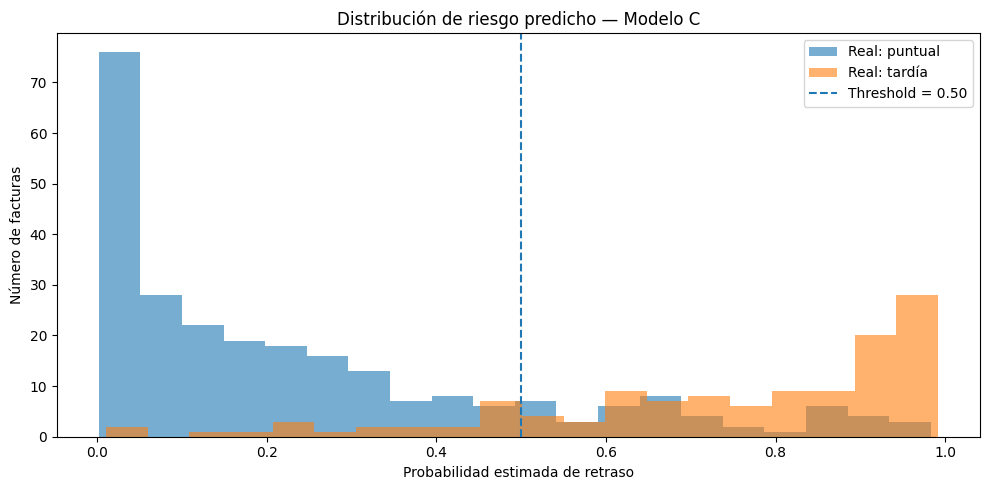

In [57]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.hist(
    y_validation_prob_c[
        y_validation.to_numpy() == 0
    ],
    bins=20,
    alpha=0.6,
    label="Real: puntual"
)

ax.hist(
    y_validation_prob_c[
        y_validation.to_numpy() == 1
    ],
    bins=20,
    alpha=0.6,
    label="Real: tardía"
)

ax.axvline(
    0.50,
    linestyle="--",
    label="Threshold = 0.50"
)

ax.set_title(
    "Distribución de riesgo predicho — Modelo C"
)

ax.set_xlabel(
    "Probabilidad estimada de retraso"
)

ax.set_ylabel(
    "Número de facturas"
)

ax.legend()

plt.tight_layout()
plt.show()

### Thresholds para C

In [68]:
threshold_results_c = pd.DataFrame([
    evaluate_threshold(
        y_validation,
        y_validation_prob_c,
        threshold
    )
    for threshold in thresholds
])

threshold_results_c.head()


,threshold,precision,recall,f1,f2,balanced_accuracy,true_negatives,false_positives,false_negatives,true_positives
0,0.10,0.443636,0.983871,0.611529,0.791180,0.694270,104,153,2,122
1,0.12,0.463878,0.983871,0.630491,0.803689,0.717616,116,141,2,122
2,0.14,0.476562,0.983871,0.642105,0.811170,0.731235,123,134,2,122
3,0.16,0.489879,0.975806,0.652291,0.814266,0.742767,131,126,3,121
4,0.18,0.512712,0.975806,0.672222,0.826503,0.764168,142,115,3,121


### Curvas de metricas

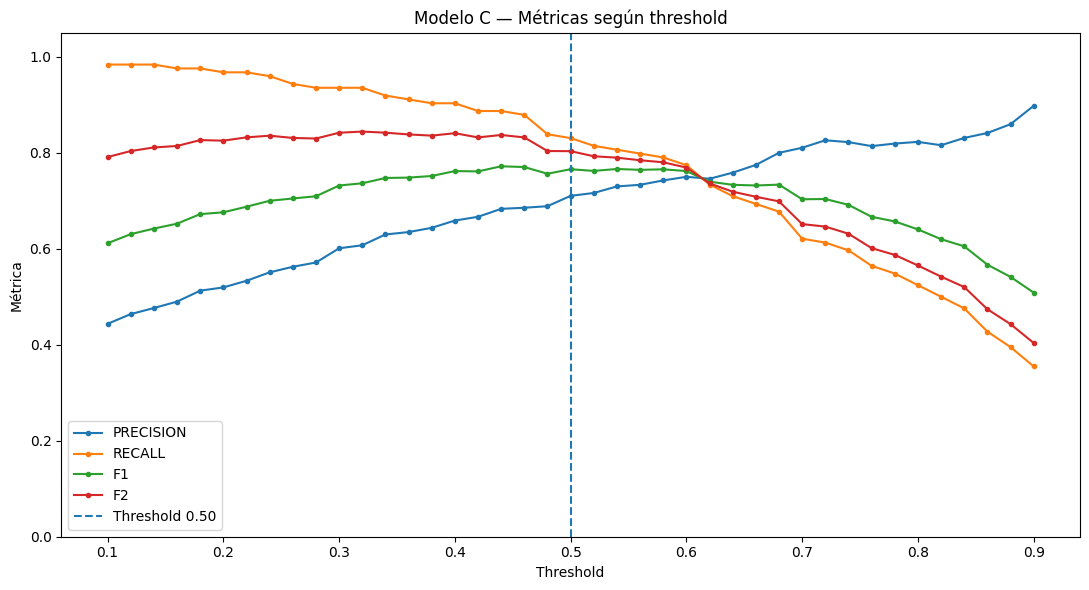

In [69]:
fig, ax = plt.subplots(
    figsize=(11, 6)
)

for metric in [
    "precision",
    "recall",
    "f1",
    "f2",
]:

    ax.plot(
        threshold_results_c["threshold"],
        threshold_results_c[metric],
        marker="o",
        markersize=3,
        label=metric.upper()
    )

ax.axvline(
    0.50,
    linestyle="--",
    label="Threshold 0.50"
)

ax.set_title(
    "Modelo C — Métricas según threshold"
)

ax.set_xlabel(
    "Threshold"
)

ax.set_ylabel(
    "Métrica"
)

ax.set_ylim(
    0,
    1.05
)

ax.legend()

plt.tight_layout()
plt.show()

### Maximizar F2

In [70]:
best_f2_row_c = (
    threshold_results_c
    .loc[
        threshold_results_c[
            "f2"
        ].idxmax()
    ]
)

best_f2_threshold_c = (
    best_f2_row_c[
        "threshold"
    ]
)

display(best_f2_row_c)

print(
    f"Threshold Max F2: "
    f"{best_f2_threshold_c:.2f}"
)

print(
    f"Precision: "
    f"{best_f2_row_c['precision']:.3f}"
)

print(
    f"Recall: "
    f"{best_f2_row_c['recall']:.3f}"
)

print(
    f"F1: "
    f"{best_f2_row_c['f1']:.3f}"
)

print(
    f"F2: "
    f"{best_f2_row_c['f2']:.3f}"
)

threshold              0.320000
precision              0.607330
recall                 0.935484
f1                     0.736508
f2                     0.844250
balanced_accuracy      0.821828
true_negatives       182.000000
false_positives       75.000000
false_negatives        8.000000
true_positives       116.000000
Name: 11, dtype: float64

Threshold Max F2: 0.32
Precision: 0.607
Recall: 0.935
F1: 0.737
F2: 0.844


### Threshold para Recal >= 90%

In [71]:
recall_target = 0.90

recall_candidates_c = (
    threshold_results_c[
        threshold_results_c[
            "recall"
        ] >= recall_target
    ]
)

if not recall_candidates_c.empty:

    recall_90_row_c = (
        recall_candidates_c
        .sort_values(
            "threshold",
            ascending=False
        )
        .iloc[0]
    )

    display(
        recall_90_row_c
        .to_frame(
            name="Recall >= 90%"
        )
    )

else:

    print(
        "No existe threshold "
        "con Recall >= 90 %."
    )

,Recall >= 90%
threshold,0.400000
precision,0.658824
recall,0.903226
f1,0.761905
f2,0.840841
balanced_accuracy,0.838772
true_negatives,199.000000
false_positives,58.000000
false_negatives,12.000000
true_positives,112.000000


### Comparativa estrategias de C

In [72]:
default_row_c = (
    evaluate_threshold(
        y_validation,
        y_validation_prob_c,
        0.50
    )
)

model_c_threshold_rows = [
    {
        "strategy": "Default 0.50",
        **default_row_c
    },
    {
        "strategy": "Max F2",
        **best_f2_row_c.to_dict()
    },
]

if not recall_candidates_c.empty:

    model_c_threshold_rows.append({
        "strategy": "Recall >= 90%",
        **recall_90_row_c.to_dict()
    })

model_c_threshold_comparison = (
    pd.DataFrame(
        model_c_threshold_rows
    )
)

model_c_threshold_comparison[
    [
        "strategy",
        "threshold",
        "precision",
        "recall",
        "f1",
        "f2",
        "balanced_accuracy",
        "false_positives",
        "false_negatives",
        "true_positives",
    ]
]

,strategy,threshold,precision,recall,f1,f2,balanced_accuracy,false_positives,false_negatives,true_positives
0,Default 0.50,0.50,0.710345,0.830645,0.765799,0.803432,0.833611,42.0,21.0,103.0
1,Max F2,0.32,0.607330,0.935484,0.736508,0.844250,0.821828,75.0,8.0,116.0
2,Recall >= 90%,0.40,0.658824,0.903226,0.761905,0.840841,0.838772,58.0,12.0,112.0


### Matriz F2

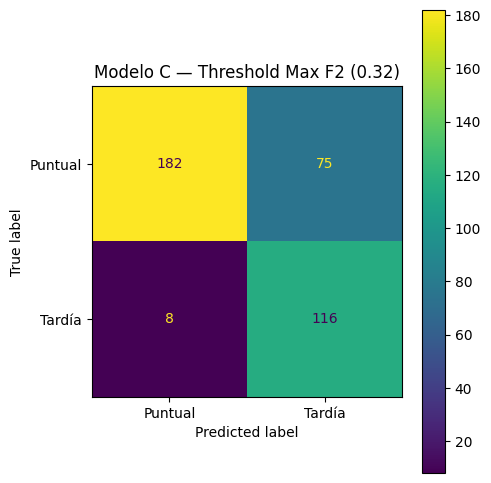

In [73]:
y_validation_pred_c_f2 = (
    y_validation_prob_c
    >= best_f2_threshold_c
).astype(int)

cm_c_f2 = confusion_matrix(
    y_validation,
    y_validation_pred_c_f2
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_c_f2,
    display_labels=[
        "Puntual",
        "Tardía"
    ]
)

fig, ax = plt.subplots(
    figsize=(5, 5)
)

disp.plot(
    ax=ax,
    values_format="d"
)

ax.set_title(
    "Modelo C — Threshold Max F2 "
    f"({best_f2_threshold_c:.2f})"
)

plt.tight_layout()
plt.show()

### ROC y PR Modelo C

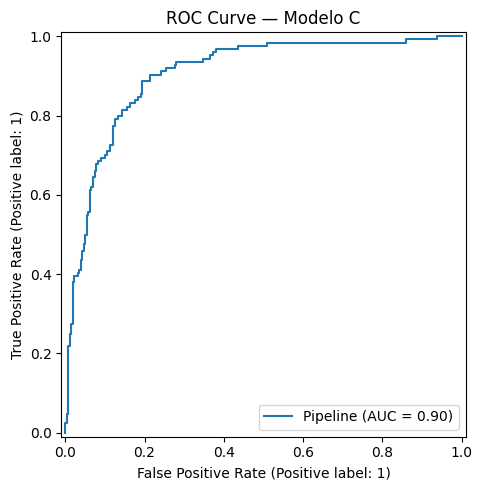

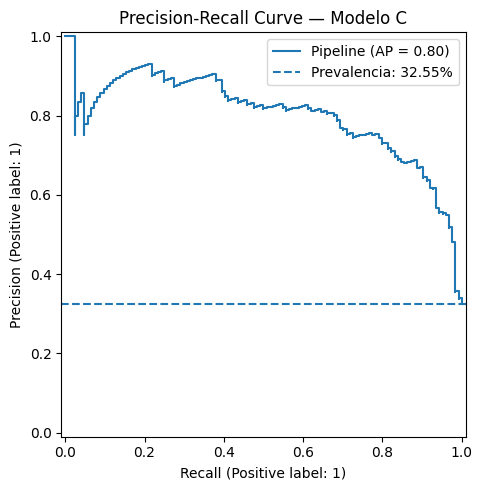

In [74]:
fig, ax = plt.subplots(
    figsize=(7, 5)
)

RocCurveDisplay.from_estimator(
    logistic_model_c,
    X_validation_c,
    y_validation,
    ax=ax
)

ax.set_title(
    "ROC Curve — Modelo C"
)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(
    figsize=(7, 5)
)

PrecisionRecallDisplay.from_estimator(
    logistic_model_c,
    X_validation_c,
    y_validation,
    ax=ax
)

ax.axhline(
    y_validation.mean(),
    linestyle="--",
    label=(
        "Prevalencia: "
        f"{y_validation.mean():.2%}"
    )
)

ax.set_title(
    "Precision-Recall Curve — Modelo C"
)

ax.legend()

plt.tight_layout()
plt.show()

### Impacto operativo

In [75]:
model_c_operational_summary = pd.DataFrame([
    {
        "strategy": "Default 0.50",
        "threshold": 0.50,
        "alerts": 42 + 103,
        "alerts_pct": (42 + 103) / len(y_validation) * 100,
        "false_positives": 42,
        "false_negatives": 21,
        "true_positives": 103,
    },
    {
        "strategy": "Max F2",
        "threshold": 0.32,
        "alerts": 75 + 116,
        "alerts_pct": (75 + 116) / len(y_validation) * 100,
        "false_positives": 75,
        "false_negatives": 8,
        "true_positives": 116,
    },
    {
        "strategy": "Recall >= 90%",
        "threshold": 0.40,
        "alerts": 58 + 112,
        "alerts_pct": (58 + 112) / len(y_validation) * 100,
        "false_positives": 58,
        "false_negatives": 12,
        "true_positives": 112,
    },
])

model_c_operational_summary

,strategy,threshold,alerts,alerts_pct,false_positives,false_negatives,true_positives
0,Default 0.50,0.50,145,38.057743,42,21,103
1,Max F2,0.32,191,50.131234,75,8,116
2,Recall >= 90%,0.40,170,44.619423,58,12,112


# Conclusiones del Model Baseline

El objetivo de este notebook era determinar si las features construidas durante el feature engineering contienen suficiente señal predictiva para anticipar el retraso de una factura y establecer un baseline supervisado antes de introducir algoritmos de mayor complejidad.

Los resultados permiten responder afirmativamente a esta pregunta.

## Baseline trivial

El `DummyClassifier`, que clasifica todas las facturas como pertenecientes a la clase mayoritaria, obtiene una accuracy cercana al 67 %.

Sin embargo, no detecta ninguna factura tardía:

- Recall = 0;
- F1 = 0;
- Balanced Accuracy = 0,50;
- ROC-AUC = 0,50.

Este resultado demuestra que la accuracy no constituye una métrica suficiente para evaluar este problema.

## Regresión logística

La primera regresión logística entrenada con el conjunto completo de features supera ampliamente al modelo trivial.

Sobre validation alcanza aproximadamente:

- Accuracy = 83,7 %;
- Balanced Accuracy = 83,3 %;
- Precision = 71,8 %;
- Recall = 82,3 %;
- F1 = 76,7 %;
- F2 = 79,9 %;
- ROC-AUC = 90,1 %;
- PR-AUC = 80,4 %.

Estos resultados demuestran que las variables construidas durante el feature engineering contienen una señal predictiva relevante.

## Ablación de features

El análisis incremental de grupos de variables muestra que la mayor parte de la capacidad predictiva procede del histórico de comportamiento del cliente.

El modelo basado únicamente en características de la factura obtiene:

- ROC-AUC ≈ 0,654;
- PR-AUC ≈ 0,513.

Añadir únicamente contexto temporal no mejora el resultado:

- ROC-AUC ≈ 0,645;
- PR-AUC ≈ 0,499.

La mejora principal aparece al incorporar el histórico del cliente:

- ROC-AUC ≈ 0,904;
- PR-AUC ≈ 0,802.

Esto supone una mejora aproximada de:

- +0,259 en ROC-AUC;
- +0,303 en PR-AUC.

El resultado confirma que el comportamiento histórico de pago constituye la principal fuente predictiva del sistema.

## Selección del Modelo C

El Modelo C, formado por características de la factura, contexto temporal e histórico del cliente, utiliza 34 features.

Sobre validation obtiene:

- Accuracy = 83,5 %;
- Balanced Accuracy = 83,4 %;
- Precision = 71,0 %;
- Recall = 83,1 %;
- F1 = 76,6 %;
- F2 = 80,3 %;
- ROC-AUC = 90,4 %;
- PR-AUC = 80,2 %.

El modelo completo con 43 features presenta un rendimiento prácticamente equivalente:

- ROC-AUC = 90,1 %;
- PR-AUC = 80,4 %.

Las nueve variables adicionales relacionadas con exposición pendiente solo incrementan PR-AUC en aproximadamente 0,0024 y reducen ligeramente ROC-AUC.

Por este motivo se selecciona el **Modelo C** como baseline supervisado principal, al mantener una capacidad predictiva equivalente o superior con menor complejidad.

## Análisis del threshold

El threshold estándar de 0,50 no es necesariamente el punto de operación más adecuado.

Con `threshold = 0.50`:

- Precision = 71,0 %;
- Recall = 83,1 %;
- F2 = 80,3 %;
- 21 retrasos no son detectados;
- 42 facturas puntuales generan una falsa alarma;
- aproximadamente el 38,1 % de las facturas sería marcado para revisión.

El threshold que maximiza F2 sobre validation es aproximadamente:

`threshold = 0.32`

Con este punto:

- Precision = 60,7 %;
- Recall = 93,5 %;
- F2 = 84,4 %;
- 8 retrasos no son detectados;
- 75 facturas puntuales generan una falsa alarma;
- aproximadamente el 50,1 % de las facturas sería marcado para revisión.

También se ha identificado un punto de operación intermedio:

`threshold = 0.40`

que mantiene un Recall superior al 90 % y obtiene:

- Precision = 65,9 %;
- Recall = 90,3 %;
- F2 = 84,1 %;
- 12 retrasos no detectados;
- 58 falsas alarmas;
- aproximadamente el 44,6 % de las facturas marcado para revisión.

La diferencia de F2 entre 0,32 y 0,40 es mínima, mientras que el threshold 0,40 reduce de forma apreciable el número de falsas alarmas y de facturas que requieren revisión.

Por este motivo, `threshold = 0.40` se considera **el candidato operativo provisional para la regresión logística**, mientras que `0.32` se conserva como referencia técnica de máximo F2.

La selección definitiva del threshold deberá considerar, si están disponibles, los costes empresariales asociados a un retraso no detectado y a una falsa alarma.

## Métricas prioritarias

La evaluación no se basa principalmente en accuracy.

Desde el punto de vista operativo se presta especial atención al Recall, ya que mide la proporción de retrasos reales que el sistema consigue anticipar.

Sin embargo, maximizar Recall de forma aislada produciría un número excesivo de falsas alarmas.

Por esta razón se utilizan conjuntamente:

- Recall, para controlar los retrasos no detectados;
- Precision, para medir la utilidad de las alertas;
- F2, como medida de equilibrio que otorga mayor importancia al Recall;
- PR-AUC, para comparar la capacidad predictiva sin depender de un threshold concreto;
- ROC-AUC, como medida complementaria de discriminación global.

## Generalización temporal

El rendimiento de validation no muestra el patrón típico de sobreajuste respecto a train.

No obstante, la proporción de facturas tardías disminuye entre los períodos de entrenamiento, validation y test.

Por ello, la generalización temporal continuará siendo uno de los principales criterios de evaluación.

## Estado del conjunto de test

El conjunto de test permanece completamente reservado.

No se ha utilizado para:

- seleccionar features;
- escoger el modelo;
- decidir el threshold;
- ajustar el preprocesamiento.

Esto permitirá realizar posteriormente una evaluación final sobre un período temporal que no ha participado en ninguna decisión de modelado.

## Veredicto

El baseline supervisado se considera satisfactorio.

La regresión logística basada en el Modelo C constituye una referencia sólida, interpretable y relativamente sencilla para el resto del proyecto.

El principal resultado hasta este punto es que el **histórico de comportamiento de pago del cliente aporta la mayor parte de la señal predictiva**, lo que respalda directamente la hipótesis empresarial original del proyecto.

El siguiente paso será estudiar la interpretabilidad del Modelo C y determinar qué variables están asociadas a un mayor o menor riesgo de retraso antes de comparar este baseline con algoritmos de mayor complejidad.